# The Identity Matrix

*Course notes for **Math for Machine Learning**, C1 · W3 · L2 · V04 — "The Identity Matrix" (DeepLearning.AI).*

Among numbers, **$1$** is special: multiplying any number by $1$ gives it back unchanged. The **identity matrix** plays exactly that role among matrices — and its linear transformation is the simplest possible one: it **leaves the plane intact**, sending every point to itself.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. What it looks like

The identity matrix has **ones on the diagonal and zeros everywhere else**:

$$ I_2 = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}, \qquad I_5 = \begin{pmatrix} 1 & 0 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 0 & 1 \end{pmatrix}. $$

In NumPy it's `np.eye(n)`.

In [2]:
print('I_2 =')
print(np.eye(2))
print()
print('I_5 =')
print(np.eye(5))

I_2 =
[[1. 0.]
 [0. 1.]]

I_5 =
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


## 2. Why it works: $I v = v$

Multiply $I$ by any vector, say $(a, b, c, d, e)$, and you get the **same vector back**. Each output entry is the dot product of a row of $I$ with the vector — and since a row of $I$ is all zeros except a single $1$, it just picks out the matching entry:

$$ (\text{row 1})\cdot(a,b,c,d,e) = 1\cdot a + 0\cdot b + 0\cdot c + 0\cdot d + 0\cdot e = a, $$

and likewise the second row gives $b$, the third $c$, and so on.

In [3]:
v = np.array([10, 20, 30, 40, 50])   # 'a, b, c, d, e'
print('I @ v =', np.eye(5) @ v)       # -> same vector
print('unchanged:', np.array_equal(np.eye(5) @ v, v))

I @ v = [10. 20. 30. 40. 50.]
unchanged: True


## 3. The multiplicative identity for matrices

Just like $1 \times n = n$, the identity matrix satisfies

$$ I\,M = M\,I = M $$

for any (compatibly-sized) matrix $M$ — it is the **neutral element** of matrix multiplication.

In [4]:
M = np.array([[3, 1],
              [1, 2]])
I = np.eye(2)
print('I @ M =')
print(I @ M)
print('M @ I =')
print(M @ I)
print('both equal M:', np.array_equal(I @ M, M) and np.array_equal(M @ I, M))

I @ M =
[[3. 1.]
 [1. 2.]]
M @ I =
[[3. 1.]
 [1. 2.]]
both equal M: True


## 4. As a transformation: it leaves the plane intact

The identity's linear transformation sends **each point to itself**: $(0,0)\to(0,0)$, $(1,0)\to(1,0)$, $(0,1)\to(0,1)$, and so on. Nothing moves, rotates, or stretches — the grid is unchanged.

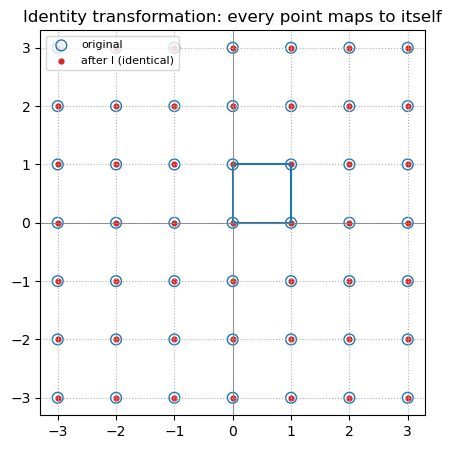

points unchanged: True


In [5]:
# A grid of points is completely unmoved by I
xs, ys = np.meshgrid(np.arange(-3, 4), np.arange(-3, 4))
pts = np.vstack([xs.ravel(), ys.ravel()])   # 2 x N
moved = np.eye(2) @ pts

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pts[0], pts[1], s=60, facecolors='none', edgecolors='C0', label='original')
ax.scatter(moved[0], moved[1], s=12, color='C3', label='after I (identical)')
square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]).T
ax.plot(square[0], square[1], color='C0')
ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.legend(loc='upper left', fontsize=8)
ax.set_title('Identity transformation: every point maps to itself')
plt.show()

print('points unchanged:', np.array_equal(moved, pts))

## Summary

- The **identity matrix** $I$ is the matrix analogue of the number **$1$**: **ones on the diagonal, zeros elsewhere** (`np.eye(n)`).
- $I v = v$ for every vector, and $I M = M I = M$ for every matrix — it's the **neutral element** of matrix multiplication.
- As a **linear transformation** it does nothing: it sends every point to itself, leaving the plane intact.